# Experiment 4 — Temperature-scaling control

Fits a single scalar temperature $T$ per model (Guo et al. 2017) and re-measures ECE. **Hypothesis:** most of VIB-SWAG's calibration gap over the deterministic baseline is a temperature artefact — after one-parameter scaling the models converge, so the uncertainty mechanisms aren't buying calibration beyond a scalar.

To avoid optimism we **fit $T$ on one half of the test set and evaluate ECE on the other half** (no validation probs were saved). For the sampling models we scale the *mean* predictive distribution via pseudo-logits $\log p$, i.e. $p_T \propto p^{1/T}$ — an approximation to scaling per-member logits (which weren't saved). Notes at the bottom on the cleaner version if you want it for the final number.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
import os
try:
    open('deterministic_results.npz')
except FileNotFoundError:
    from google.colab import drive; drive.mount('/content/drive')
    os.chdir('/content/drive/MyDrive/thesis_results')

MODELS = [('Deterministic', 'deterministic_results.npz'),
          ('MC Dropout',    'mc_dropout_results.npz'),
          ('SWAG',          'swag_results.npz'),
          ('VIB',           'vib_alone_results.npz'),
          ('Deep Ensemble', 'deep_ensemble_5_results.npz'),
          ('VIB-SWAG',      'vib_swag_results.npz')]

def ece(probs, labels, n_bins=15):
    conf = probs.max(1); pred = probs.argmax(1)
    correct = (pred == labels).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(conf, edges[1:-1], right=True), 0, n_bins - 1)
    e = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.any():
            e += m.mean() * abs(correct[m].mean() - conf[m].mean())
    return float(e)

def nll(probs, labels, eps=1e-12):
    p = np.clip(probs, eps, 1)
    return float(-np.log(p[np.arange(len(labels)), labels]).mean())

def temp_scale(probs, T, eps=1e-12):
    logp = np.log(np.clip(probs, eps, 1)) / T
    logp -= logp.max(1, keepdims=True)
    e = np.exp(logp)
    return e / e.sum(1, keepdims=True)

Mounted at /content/drive


In [2]:
rng = np.random.default_rng(0)
rows = []
for name, f in MODELS:
    if not os.path.exists(f):
        print('skip (missing):', f); continue
    d = np.load(f, allow_pickle=False)
    probs, labels = d['probs_test'], d['labels_test']

    # Split test into fit / eval halves
    perm = rng.permutation(len(labels))
    half = len(labels) // 2
    fit, ev = perm[:half], perm[half:]

    T = minimize_scalar(lambda t: nll(temp_scale(probs[fit], t), labels[fit]),
                        bounds=(0.3, 10.0), method='bounded').x
    rows.append({
        'Model': name, 'T': T,
        'ECE before': ece(probs[ev], labels[ev]),
        'ECE after':  ece(temp_scale(probs[ev], T), labels[ev]),
        'NLL before': nll(probs[ev], labels[ev]),
        'NLL after':  nll(temp_scale(probs[ev], T), labels[ev]),
    })
ts = pd.DataFrame(rows).set_index('Model')
display(ts.round(4)); ts.to_csv('temperature_scaling.csv')

,T,ECE before,ECE after,NLL before,NLL after
Model,,,,,
Deterministic,1.6613,0.0406,0.0104,0.3014,0.2613
MC Dropout,1.3603,0.0253,0.0102,0.2883,0.2705
SWAG,1.5054,0.0387,0.0074,0.2963,0.2679
VIB,2.0910,0.0581,0.0157,0.4105,0.2823
Deep Ensemble,0.9856,0.0076,0.0088,0.2222,0.2224
VIB-SWAG,1.9640,0.0433,0.0110,0.3130,0.2563


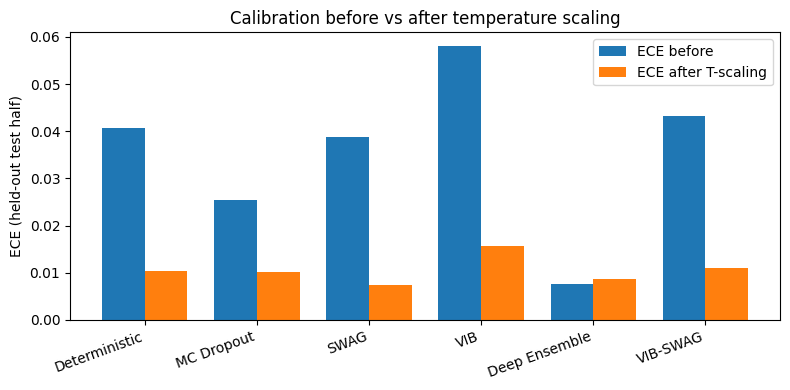

In [3]:
x = np.arange(len(ts)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - w/2, ts['ECE before'], w, label='ECE before')
ax.bar(x + w/2, ts['ECE after'],  w, label='ECE after T-scaling')
ax.set_xticks(x); ax.set_xticklabels(ts.index, rotation=20, ha='right')
ax.set_ylabel('ECE (held-out test half)'); ax.set_title('Calibration before vs after temperature scaling')
ax.legend(); plt.tight_layout(); plt.savefig('temperature_scaling.png', dpi=130, bbox_inches='tight'); plt.show()

**Reading it.** If the "after" bars collapse to a similar low level across models, a single scalar explains most of the calibration differences and the mechanisms add little calibration value of their own. The fitted $T$ itself is informative: $T>1$ means the raw model was over-confident.

**Cleaner version for the final number (optional).** Fit $T$ on the *validation* set: add `probs_val=...`, `labels_val=...` to each model notebook's `np.savez`, then fit $T$ on val and report ECE on the full test set. For the sampling models, the most correct temperature scaling divides each member's *logits* by $T$ before averaging; that needs per-member logits saved, which is a small change to those notebooks if you want it.